<a href="https://colab.research.google.com/github/melia1702/Pertemuan-keempat/blob/main/Latihan_2_Pertemuan_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== ADAPTIVE MEDICAL IMAGE ENHANCEMENT ===

Upload medical image (X-ray/MRI/CT/Ultrasound)


Saving download (1).jpg to download (1) (3).jpg
Image loaded: download (1) (3).jpg


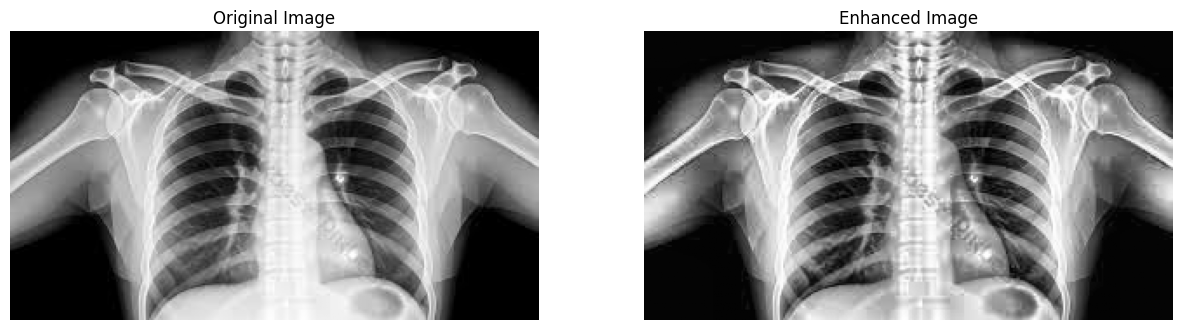


=== ENHANCEMENT REPORT ===


,Modality,Entropy Before,Entropy After,Contrast Before,Contrast After,PSNR,SSIM
0,X-ray,7.245699,7.447584,83.085352,80.230564,21.08929,0.790138


In [4]:
# ============================================================
# ADAPTIVE MEDICAL IMAGE ENHANCEMENT PIPELINE
# Compatible with Google Colab
# ============================================================

# ================================
# 1. INSTALL & IMPORT LIBRARY
# ================================
!pip -q install opencv-python scikit-image matplotlib

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import pandas as pd

print("=== ADAPTIVE MEDICAL IMAGE ENHANCEMENT ===")


# ================================
# 2. HELPER FUNCTIONS
# ================================

def calculate_entropy(image):
    """Calculate entropy of image"""
    hist = cv2.calcHist([image],[0],None,[256],[0,256])
    hist = hist / hist.sum()
    hist = hist[hist>0]
    entropy = -np.sum(hist * np.log2(hist))
    return entropy


def calculate_contrast(image):
    """Calculate contrast using standard deviation"""
    return np.std(image)


def show_images(images, titles):
    plt.figure(figsize=(15,5))

    for i in range(len(images)):
        plt.subplot(1,len(images),i+1)
        plt.imshow(images[i], cmap='gray')
        plt.title(titles[i])
        plt.axis('off')

    plt.show()


# ================================
# 3. MAIN ENHANCEMENT FUNCTION
# ================================

def medical_image_enhancement(medical_image, modality='X-ray'):
    """
    Adaptive enhancement for medical images

    Parameters:
    medical_image: Input medical image
    modality: Image modality ('X-ray', 'MRI', 'CT', 'Ultrasound')

    Returns:
    Enhanced image and enhancement report
    """

    original = medical_image.copy()

    # =========================
    # Enhancement per modality
    # =========================

    if modality == 'X-ray':
        # Improve bone contrast
        clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
        enhanced = clahe.apply(original)

    elif modality == 'MRI':
        # MRI usually noisy -> denoise + contrast enhance
        denoise = cv2.GaussianBlur(original,(5,5),0)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        enhanced = clahe.apply(denoise)

    elif modality == 'CT':
        # CT enhancement with normalization + CLAHE
        norm = cv2.normalize(original,None,0,255,cv2.NORM_MINMAX)
        norm = norm.astype(np.uint8)
        clahe = cv2.createCLAHE(clipLimit=2.5,tileGridSize=(8,8))
        enhanced = clahe.apply(norm)

    elif modality == 'Ultrasound':
        # Ultrasound often speckle noise
        denoise = cv2.medianBlur(original,5)
        clahe = cv2.createCLAHE(clipLimit=2.0,tileGridSize=(8,8))
        enhanced = clahe.apply(denoise)

    else:
        print("Unknown modality -> using default CLAHE")
        clahe = cv2.createCLAHE()
        enhanced = clahe.apply(original)

    # =========================
    # METRICS CALCULATION
    # =========================

    entropy_before = calculate_entropy(original)
    entropy_after = calculate_entropy(enhanced)

    contrast_before = calculate_contrast(original)
    contrast_after = calculate_contrast(enhanced)

    psnr_val = psnr(original, enhanced)
    ssim_val = ssim(original, enhanced)

    report = {
        "Modality": modality,
        "Entropy Before": entropy_before,
        "Entropy After": entropy_after,
        "Contrast Before": contrast_before,
        "Contrast After": contrast_after,
        "PSNR": psnr_val,
        "SSIM": ssim_val
    }

    return enhanced, report


# ================================
# 4. UPLOAD IMAGE
# ================================

print("\nUpload medical image (X-ray/MRI/CT/Ultrasound)")
uploaded = files.upload()

filename = list(uploaded.keys())[0]

image = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)

print("Image loaded:", filename)


# ================================
# 5. SELECT MODALITY
# ================================

modality = "X-ray"  # ganti: MRI / CT / Ultrasound


# ================================
# 6. RUN ENHANCEMENT
# ================================

enhanced_image, report = medical_image_enhancement(image, modality)


# ================================
# 7. SHOW RESULT
# ================================

show_images(
    [image, enhanced_image],
    ["Original Image", "Enhanced Image"]
)


# ================================
# 8. DISPLAY REPORT
# ================================

report_df = pd.DataFrame([report])

print("\n=== ENHANCEMENT REPORT ===")
display(report_df)